# Paper Figures

This notebook contains the final figures for the ICML 2026 workshop submission.

In [1]:
import math
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

FIG_PATH = Path("/Users/lukar/Code/llama-mobile/figs")

### Main Figure

**Important**: All points on the plot should have a fixed format + varying block sizes, and have a **fixed** number of steps for a fair comparison.
- Currently: student-t fitted + block scaling, at 2k steps. Probably need 4k steps instead (8k overall led to degradation).
- **TODO**: Our format added and highlighted on the plot.
- **TODO**: Add 0 steps (no QAT) points to showcase the effect of training.
- **TODO**: Change average accuracy as the overall metric.

In [2]:
api = wandb.Api()

In [3]:
# Return per-task metric
def get_metric(task: str) -> str:
    from eval.vqa import TASKS

    metrics = TASKS[task].METRICS
    assert len(metrics) == 1
    return metrics[0]


# Final metric for Fig. 1
def overall_metric(x: list[float]) -> float:
    return sum(x) / len(x)


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["size"] = run.config["n_bits"] / (8 * 10**6)
    d["n_steps"] = run.config["training"]["n_steps"]
    fmt = run.config["quantisation"]["fmt"]
    _type = fmt["_type"]
    if _type == "linear":
        d["fmt"] = fmt["element_format"]["_type"]
        if d["fmt"] == "lut":
            name = fmt["element_format"]["name"]
            df = int(name.split("[")[1].split("]")[0])
            d["fmt"] = f"student-t [df={df}]"

    elif _type == "fit_scaled" and fmt["element_family"] == "t":
        d["fmt"] = "student-t [fit]"
    else:
        raise ValueError

    scores = []
    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m = get_metric(task)
        s = run.summary[f"downstream.{task}.{m}"]
        scores.append(s)
        d[task] = s

    d["overall"] = overall_metric(scores)

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [4]:
# NOTE: Check I'm getting the right runs!
# - currently runs from "20260310-NewPrompts"

runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "formats-18-03-26", "state": "finished"},
)

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [6]:
# NOTE: Only plotting student-t [fit] as it's the best one + fixing number of steps
fmt_name = "student-t [fit]"
n_steps = 2048
df = df[(df["fmt"] == fmt_name) & (df["n_steps"] == n_steps)]

In [7]:
df

,name,size,n_steps,fmt,vqa,ai2d,chartqa,docvqa,overall,train_loss,val_loss
2,divine-sunset-1734,3340.53095,2048,student-t [fit],0.609701,0.344727,0.448242,0.381715,0.446096,0.070962,0.107597
9,crisp-snow-1741,4673.85767,2048,student-t [fit],0.756836,0.633789,0.697266,0.809677,0.724392,0.027599,0.035960
10,eager-snowball-1742,4340.52599,2048,student-t [fit],0.741536,0.669922,0.697266,0.829911,0.734659,0.029893,0.039860
11,balmy-grass-1743,4173.86015,2048,student-t [fit],0.739909,0.578125,0.708984,0.809101,0.709030,0.031657,0.043444
12,comic-wildflower-1744,5507.18687,2048,student-t [fit],0.738281,0.580078,0.744141,0.857220,0.729930,0.011483,0.013012
13,mild-capybara-1745,3007.19927,2048,student-t [fit],0.601888,0.065430,0.375000,0.167215,0.302383,0.078639,0.123102
14,mild-frog-1746,6007.18439,2048,student-t [fit],0.756836,0.667969,0.742188,0.880694,0.761921,0.009549,0.010561
15,ethereal-music-1747,2840.53343,2048,student-t [fit],0.615560,0.340820,0.373047,0.377529,0.426739,0.080358,0.126078
16,stellar-snow-1748,5673.85271,2048,student-t [fit],0.746094,0.623047,0.753906,0.847234,0.742570,0.010601,0.011410


In [8]:
# NOTE: bfloat16 baseline (whole-fire-1607)
baseline_run = api.runs(
    "graphcore/llama-mobile",
    filters={"display_name": "whole-fire-1607", "state": "finished"},
)[0]
baseline = {}
for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
    m = get_metric(task)
    baseline[task] = baseline_run.summary[f"downstream.{task}.{m}"]
baseline["overall"] = overall_metric(baseline.values())
baseline_size = baseline_run.config["n_bits"] / (8 * 10**6)
display(baseline)
print(f"Baseline size: {baseline_size:.0f}MB")

{'ai2d': 0.630859375,
 'chartqa': 0.7470703125,
 'docvqa': 0.8444538116455078,
 'vqa': 0.7542318105697632,
 'overall': 0.7441538274288177}

Baseline size: 21340MB


In [9]:
# NOTE: Plot "overall" performance

# # TODO: Add our datapoint
our_size = 3500
our_perf = 0.7
# ax = sns.scatterplot(
#     data=df, x="size", y="overall", label="Student-t + block scaling", alpha=0.8
# )
# ax.axhline(baseline["overall"], linestyle="--", color="black")
# ax.set_xlabel("Model size [MB]")
# ax.set_ylabel("Average task performance")

# ax.scatter(
#     [our_size],
#     [our_perf],
#     marker="*",
#     s=300,  # star size
#     color="crimson",
#     edgecolor="black",
#     linewidth=0.8,
#     zorder=10,
#     # label="Our format",
# )
# ax.text(our_size + 100, our_perf - 0.03, "Our format", va="center")
# ax.set_title("Model performance vs. size")

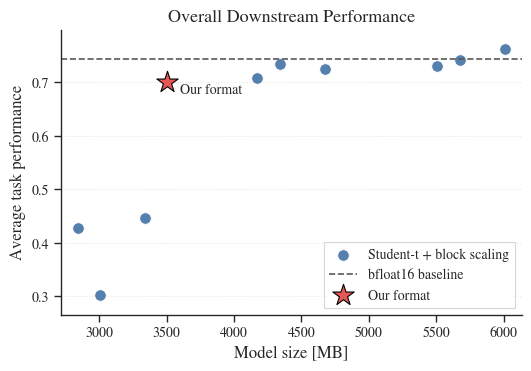

In [10]:
# NOTE: ICML-style presentation pass for the overall plot
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)

sns.scatterplot(
    data=df,
    x="size",
    y="overall",
    ax=ax,
    s=70,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.95,
    label="Student-t + block scaling",
)

ax.axhline(
    baseline["overall"],
    linestyle="--",
    linewidth=1.2,
    color="0.35",
    label="bfloat16 baseline",
)
ax.scatter(
    [our_size],
    [our_perf],
    marker="*",
    s=260,
    color="#E45756",
    edgecolor="black",
    linewidth=0.8,
    zorder=10,
    label="Our format",
)

ax.annotate(
    "Our format",
    xy=(our_size, our_perf),
    xytext=(10, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="bottom",
)

ax.set_title("Overall Downstream Performance")
ax.set_xlabel("Model size [MB]")
ax.set_ylabel("Average task performance")
ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.5)
ax.margins(x=0.04, y=0.08)
sns.despine(ax=ax)
ax.legend(loc="lower right", frameon=True, fancybox=False, edgecolor="0.8")

# Save as vector art for cleaner inclusion in LaTeX if needed.
fig.savefig(FIG_PATH / "fig1.pdf", bbox_inches="tight")

plt.show()

In [11]:
# fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# axes = axes.flatten()
# tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
# for ax, task in zip(axes, tasks):
#     sns.scatterplot(data=df, x="size", y=task, ax=ax)
    
#     ax.axhline(baseline[task], linestyle="--", color="black")
    
#     ax.set_title(task.upper())
#     ax.set_xlabel("Model size [MB]")
#     m = get_metric(task)
#     ax.set_ylabel(m)
    

# plt.tight_layout()
# plt.show()

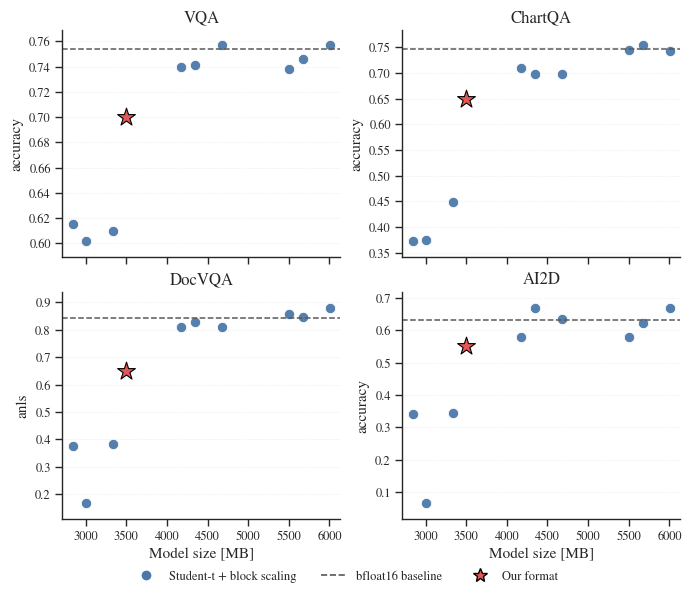

In [12]:
# NOTE: ICML-style presentation pass for the per-task plots
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# TODO: Change with actual data
# our_task_scores = None
our_task_scores = {
    "vqa": 0.7,
    "chartqa": 0.65,
    "docvqa": 0.65,
    "ai2d": 0.55,
}

fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.6), sharex=True, constrained_layout=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
task_titles = {
    "vqa": "VQA",
    "chartqa": "ChartQA",
    "docvqa": "DocVQA",
    "ai2d": "AI2D",
}

for ax, task in zip(axes, tasks):
    sns.scatterplot(
        data=df,
        x="size",
        y=task,
        ax=ax,
        s=55,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

    ax.axhline(baseline[task], linestyle="--", linewidth=1.1, color="0.35")

    if our_task_scores is not None:
        ax.scatter(
            [our_size],
            [our_task_scores[task]],
            marker="*",
            s=180,
            color="#E45756",
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
        )

    ax.set_title(task_titles[task])
    ax.set_xlabel("Model size [MB]")
    ax.set_ylabel(get_metric(task))
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.45)
    ax.margins(x=0.04, y=0.08)
    sns.despine(ax=ax)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", markersize=6, color="#4C78A8", label="Student-t + block scaling"),
    plt.Line2D([], [], linestyle="--", color="0.35", label="bfloat16 baseline"),
]
if our_task_scores is not None:
    handles.append(
        plt.Line2D([], [], marker="*", linestyle="", markersize=10, color="#E45756", markeredgecolor="black", label="Our format")
    )

fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.05))

# Save as vector art for cleaner inclusion in LaTeX if needed.
fig.savefig(FIG_PATH / "fig_tasks.pdf", bbox_inches="tight")

plt.show()


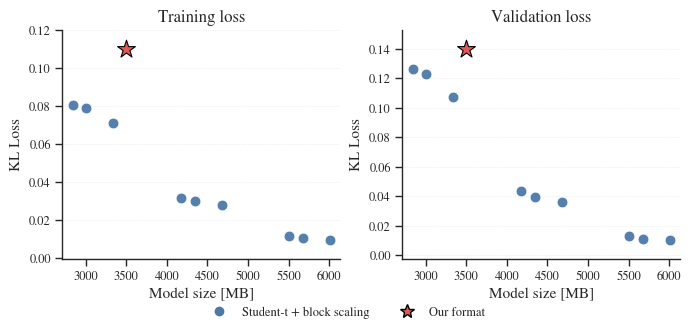

In [ ]:
# NOTE: ICML-style presentation pass for the loss plots
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

loss_specs = [
    ("train_loss", "Training loss"),
    ("val_loss", "Validation loss"),
]

# TODO: Change with actual data
our_loss_scores = {
    "train_loss": 0.06,
    "val_loss": 0.08,
}

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.0), constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    panel_df = df.dropna(subset=[key])
    sns.scatterplot(
        data=panel_df,
        x="size",
        y=key,
        ax=ax,
        s=60,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

    if our_loss_scores is not None:
        ax.scatter(
            [our_size],
            [our_loss_scores[key]],
            marker="*",
            s=180,
            color="#E45756",
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
        )

    ax.set_title(title)
    ax.set_xlabel("Model size [MB]")
    ax.set_ylabel("KL Loss")
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.45)
    ax.margins(x=0.04, y=0.10)
    sns.despine(ax=ax)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", markersize=6, color="#4C78A8", label="Student-t + block scaling"),
]
if our_loss_scores is not None:
    handles.append(
        plt.Line2D([], [], marker="*", linestyle="", markersize=10, color="#E45756", markeredgecolor="black", label="Our format")
    )
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.08))

# Save as vector art for cleaner inclusion in LaTeX if needed.
# fig.savefig(FIG_PATH / "fig_loss.pdf", bbox_inches="tight")

plt.show()
